In [1]:
from google.colab import files
import pandas as pd
import json

uploaded = files.upload()

Saving meta-Montana.json to meta-Montana.json


In [11]:
from io import StringIO

file_content = next(iter(uploaded.values())).decode('utf-8')
df = pd.read_json(StringIO(file_content), lines=True)

# Task
Analyze the "meta-Montana.json" dataset to understand Google Maps locations in Montana by:
1. Inspecting the data structure.
2. Identifying the most popular and highest-rated categories.
3. Analyzing nightlife venues (9 PM - 6 AM, weekdays vs. weekends).
4. Investigating the 'relative_results' column to understand connections between locations.
5. Finding the top 5 closest points for each location based on coordinates and analyzing their categories.
6. Summarizing all findings.

In [12]:
df.head()

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url
0,"Big Sky Truck & Equipment, Inc.","Big Sky Truck & Equipment, Inc., 6494 U.S. Hig...",0x535dc557d042b1f3:0xc419b6f55435c7de,None,46.933522,-114.106515,"[Truck accessories store, Diesel engine dealer...",3.0,2,None,"[[Thursday, 8AM–5PM], [Friday, 8AM–5PM], [Satu...","{'Service options': ['In-store pickup', 'In-st...",Open ⋅ Closes 5PM,"[0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6, 0x535d...",https://www.google.com/maps/place//data=!4m2!3...
1,Wheelbarrow Creek Ranch,"Wheelbarrow Creek Ranch, 1506 Wheelbarrow Cree...",0x535c2690c357f3bd:0x272620bb52fecf11,None,46.582787,-113.950324,[Ranch],5.0,2,None,None,None,Open now,"[0x535e993bd79abfed:0xef2dffa2c4d450b1, 0x535e...",https://www.google.com/maps/place//data=!4m2!3...
2,Montana Saws,"Montana Saws, 3779 Eastside Hwy, Stevensville,...",0x535e9ec3ce050deb:0x2169887374ce879f,None,46.499112,-114.093649,"[Small engine repair service, Garden center]",4.7,28,None,"[[Thursday, 9AM–6PM], [Friday, 9AM–6PM], [Satu...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 6PM,"[0x535ea2b8fc78a29d:0x4afec6e772204072, 0x535e...",https://www.google.com/maps/place//data=!4m2!3...
3,Regis Salon,"Regis Salon, 2901 Brooks St Ste B-12, Missoula...",0x535dcd8d0868cfd1:0xa4bcdf67cf1f3a76,None,46.846230,-114.026820,"[Hair salon, Barber shop, Beauty salon, Hairdr...",3.3,38,None,"[[Thursday, 10AM–9PM], [Friday, 10AM–9PM], [Sa...",{'Accessibility': ['Wheelchair accessible entr...,Permanently closed,"[0x535dcdf32d35aa99:0x759cd7bfffe9b23a, 0x535d...",https://www.google.com/maps/place//data=!4m2!3...
4,Ferguson Plumbing Supply,"Ferguson Plumbing Supply, 3843 Brooks St, Miss...",0x56c663acaebf110b:0x117445f25e7e988a,"Wholesale distributor of plumbing, HVAC, water...",46.836223,-114.041582,"[Plumbing supply store, Bathroom supply store,...",4.6,5,$$,"[[Thursday, 7AM–5PM], [Friday, 7AM–5PM], [Satu...","{'Service options': ['Curbside pickup', 'Deliv...",Open ⋅ Closes 5PM,"[0x535dcde9d8e76fe1:0xe0b24cd42cf705d7, 0x535d...",https://www.google.com/maps/place//data=!4m2!3...


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21680 entries, 0 to 21679
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              21680 non-null  object 
 1   address           21371 non-null  object 
 2   gmap_id           21680 non-null  object 
 3   description       2607 non-null   object 
 4   latitude          21680 non-null  float64
 5   longitude         21680 non-null  float64
 6   category          21590 non-null  object 
 7   avg_rating        21680 non-null  float64
 8   num_of_reviews    21680 non-null  int64  
 9   price             3001 non-null   object 
 10  hours             14984 non-null  object 
 11  MISC              16651 non-null  object 
 12  state             13968 non-null  object 
 13  relative_results  18926 non-null  object 
 14  url               21680 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 2.5+ MB


In [14]:
df.describe()

,latitude,longitude,avg_rating,num_of_reviews
count,21680.000000,21680.000000,21680.000000,21680.000000
mean,46.699219,-111.588271,4.382417,89.203828
std,1.055297,2.540371,0.597772,210.326785
min,30.407180,-122.601452,1.000000,1.000000
25%,45.773883,-114.028596,4.100000,7.000000
50%,46.593247,-111.856159,4.500000,24.000000
75%,47.510949,-109.954550,4.800000,78.000000
max,48.999018,-97.559348,5.000000,9788.000000


In [16]:
df.shape

(21680, 15)

In [17]:
df.isnull().sum()

,0
name,0
address,309
gmap_id,0
description,19073
latitude,0
longitude,0
category,90
avg_rating,0
num_of_reviews,0
price,18679


In [18]:
import ast

# Check the type of the first non-null entry in the "category" column
# Fill missing values with an empty list string representation for consistency
# Then convert string representations of lists into actual lists

first_category_entry = df['category'].dropna().iloc[0] if not df['category'].dropna().empty else None
df['category_list'] = df['category'].fillna('[]').apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df[['category', 'category_list']].head()

,category,category_list
0,"[Truck accessories store, Diesel engine dealer...","[Truck accessories store, Diesel engine dealer..."
1,[Ranch],[Ranch]
2,"[Small engine repair service, Garden center]","[Small engine repair service, Garden center]"
3,"[Hair salon, Barber shop, Beauty salon, Hairdr...","[Hair salon, Barber shop, Beauty salon, Hairdr..."
4,"[Plumbing supply store, Bathroom supply store,...","[Plumbing supply store, Bathroom supply store,..."


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a single list of all individual categories by iterating through the "category" column.
# Count the occurrences of each unique category.
# Select the top 18 most frequent categories for visualization.
all_categories = df.explode('category_list')['category_list']
category_counts = all_categories.value_counts()
N = 18
top_categories = category_counts.head(N)
top_categories

,count
category_list,
Restaurant,1151
Bar,706
Gas station,666
Tourist attraction,576
Campground,482
Auto repair shop,480
Coffee shop,477
Fast food restaurant,450
Hotel,439


/tmp/ipython-input-776382313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


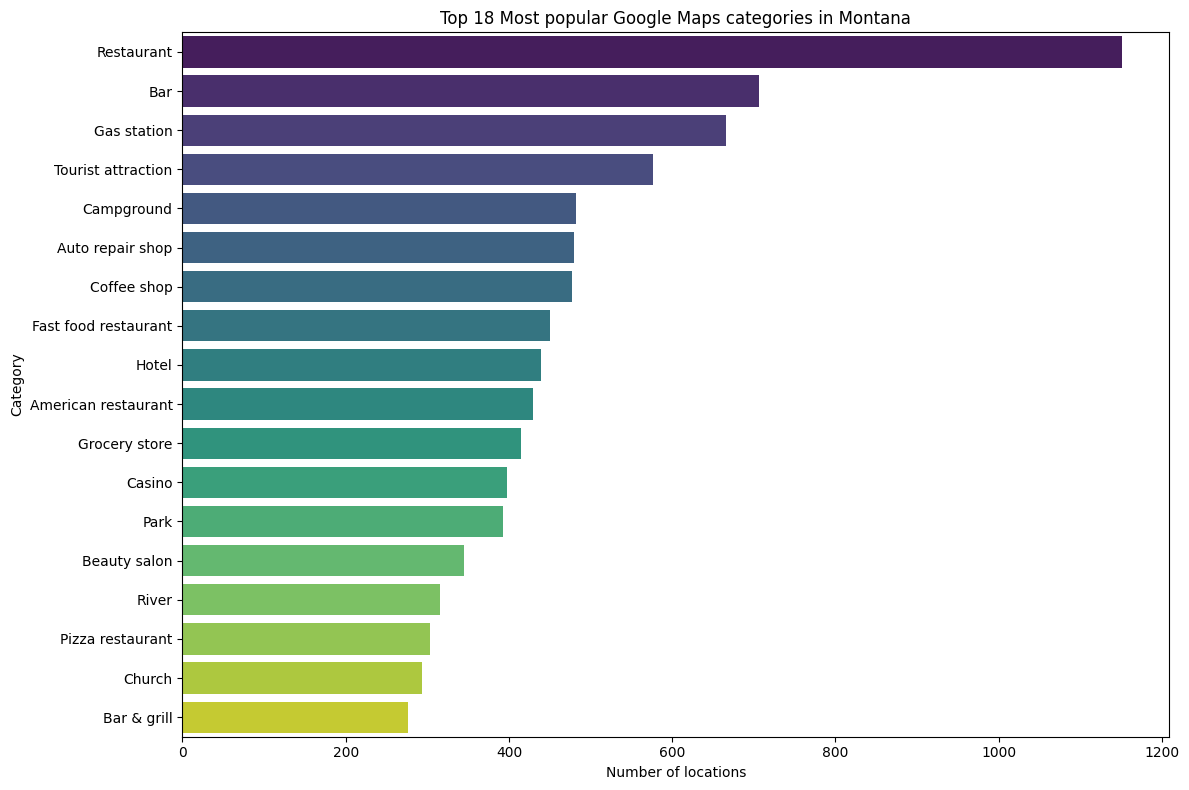

In [20]:
# Create a bar chart to visualize top categories and their counts
plt.figure(figsize=(12, 8))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.xlabel('Number of locations')
plt.ylabel('Category')
plt.title(f'Top {N} Most popular Google Maps categories in Montana')
plt.tight_layout()
plt.show()

In [22]:
import numpy as np

# Create a temporary DataFrame by exploding the category_list column so that each row represents one category instance,
# merge it with the original DataFrame to include avg_rating and num_of_reviews, and then group by category to compute
# a weighted average rating where the weights are the number of reviews.
category_df = df.explode('category_list')[['category_list', 'avg_rating', 'num_of_reviews']]
category_df['weighted_rating'] = category_df['avg_rating'] * category_df['num_of_reviews']
category_ratings = category_df.groupby('category_list').agg(
    total_weighted_rating=('weighted_rating', 'sum'),
    total_reviews=('num_of_reviews', 'sum')
).reset_index()

category_ratings['average_rating'] = category_ratings['total_weighted_rating'] / category_ratings['total_reviews']
category_ratings.head()

,category_list,total_weighted_rating,total_reviews,average_rating
0,ATM,46142.0,11011,4.190537
1,ATV dealer,10329.0,2405,4.294802
2,ATV rental service,3348.2,694,4.824496
3,ATV repair shop,5468.5,1248,4.381811
4,Abortion clinic,198.4,46,4.313043


In [23]:
MIN_REVIEWS_THRESHOLD = 50
filtered_category_ratings = category_ratings[category_ratings['total_reviews'] >= MIN_REVIEWS_THRESHOLD]
top_rated_categories = filtered_category_ratings.sort_values(by='average_rating', ascending=False).head(N)
top_rated_categories

,category_list,total_weighted_rating,total_reviews,average_rating
37,Air conditioning store,1280.0,256,5.0
528,Corporate gift supplier,365.0,73,5.0
527,Corporate entertainment service,1925.0,385,5.0
932,General practitioner,420.0,84,5.0
822,Firearms academy,325.0,65,5.0
381,Certification agency,290.0,58,5.0
1076,Hospice,700.0,140,5.0
481,Commercial real estate inspector,680.0,136,5.0
1142,Insurance school,690.0,138,5.0
1809,Sailing club,540.0,108,5.0


In [26]:
# Define a list of nightlife-related categories, filter the DataFrame to create df_nightlife
# by selecting locations whose category_list contains at least one of these categories,
# and then inspect the structure of the hours column in the resulting DataFrame.
nightlife_categories = [
    'Bar', 'Night club', 'Pub', 'Brewery', 'Lounge', 'Casino', 'Cocktail bar',
    'Sports bar', 'Dance club', 'Discothèque', 'Wine bar', 'Karaoke',
    'Live music venue', 'Comedy club', 'Gentlemen\'s club', 'Restaurant',
    'Hotel', 'Inn', 'Resort'
]

df_nightlife = df[df['category_list'].apply(lambda x: any(cat in nightlife_categories for cat in x))].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Nightlife DataFrame shape: {df_nightlife.shape}")

first_non_null_hours = df_nightlife['hours'].dropna().iloc[0] if not df_nightlife['hours'].dropna().empty else None
print(f"Type of first non-null 'hours' entry: {type(first_non_null_hours)}")
print(f"Content of first non-null 'hours' entry:\n{first_non_null_hours}")

Original DataFrame shape: (21680, 16)
Nightlife DataFrame shape: (2597, 16)
Type of first non-null 'hours' entry: <class 'list'>
Content of first non-null 'hours' entry:
[['Thursday', '4–8PM'], ['Friday', '4–8PM'], ['Saturday', '4–8PM'], ['Sunday', 'Closed'], ['Monday', 'Closed'], ['Tuesday', '4–8PM'], ['Wednesday', '4–8PM']]


In [27]:
# Define a function to parse the "hours" column
import re


def parse_hours(hours_data):
    if isinstance(hours_data, float) and np.isnan(hours_data):
        return []
    parsed_list = []
    if isinstance(hours_data, list):
        for entry in hours_data:
            if isinstance(entry, list) and len(entry) == 2:
                day = entry[0]
                time_str = entry[1]
                parsed_list.append({'day': day, 'hours': time_str})
            elif isinstance(entry, str):
                if ':' in entry:
                    parts = entry.split(':', 1)
                    parsed_list.append({'day': parts[0].strip(), 'hours': parts[1].strip()})
    return parsed_list

df_nightlife['parsed_hours'] = df_nightlife['hours'].apply(parse_hours)
df_nightlife[['hours', 'parsed_hours']].head()

,hours,parsed_hours
12,"[[Thursday, 4–8PM], [Friday, 4–8PM], [Saturday...","[{'day': 'Thursday', 'hours': '4–8PM'}, {'day'..."
36,None,[]
87,"[[Wednesday, 8AM–2AM], [Thursday, 8AM–2AM], [F...","[{'day': 'Wednesday', 'hours': '8AM–2AM'}, {'d..."
91,"[[Wednesday, 11AM–9PM], [Thursday, 11AM–9PM], ...","[{'day': 'Wednesday', 'hours': '11AM–9PM'}, {'..."
104,"[[Wednesday, 9AM–2AM], [Thursday, 9AM–2AM], [F...","[{'day': 'Wednesday', 'hours': '9AM–2AM'}, {'d..."


In [29]:
# parses messy opening-hour strings into 24-hour times and then robustly checks whether a place is open at any
# point during the night interval (9 PM–6 AM), correctly handling closed days and schedules that cross midnight.
import datetime

def parse_time_range(time_str):
    if time_str == 'Closed':
        return None, None
    time_str = time_str.replace('–', '-')
    try:
        start_str, end_str = time_str.split('-')
    except ValueError:
        if '24 hours' in time_str.lower():
            return datetime.time(0, 0), datetime.time(23, 59)
        return None, None

    def convert_to_24h(t_str):
        t_str = t_str.strip()
        time_formats = [
            '%I:%M%p',
            '%I%p',
            '%H:%M',
            '%H'
        ]

        for fmt in time_formats:
            try:
                if '%p' in fmt:
                    dt = datetime.datetime.strptime(t_str.upper(), fmt)
                else:
                    dt = datetime.datetime.strptime(t_str, fmt)
                return dt.time()
            except ValueError:
                continue
        return None

    start_time = convert_to_24h(start_str)
    end_time = convert_to_24h(end_str)

    return start_time, end_time

def is_open_at_night(parsed_hours_list, check_day, start_night=datetime.time(21, 0), end_night=datetime.time(6, 0)):
    if not parsed_hours_list:
        return False

    for entry in parsed_hours_list:
        day = entry['day']
        hours_str = entry['hours']

        if day == check_day:
            start_open, end_open = parse_time_range(hours_str)
            if start_open is None or end_open is None:
                return False
            if start_open <= end_open:
                if (start_open <= start_night < end_open) or (start_night <= start_open < end_night):
                    return True
            else:
                if start_open <= start_night or end_night <= end_open:
                    if (start_open <= start_night and end_open >= end_night) or \
                       (start_open <= start_night and start_night < datetime.time(23, 59, 59)) or \
                       (end_open >= end_night and end_night > datetime.time(0,0,0)):
                        return True
                    if start_open <= datetime.time(23, 59) and (start_open <= start_night or start_night < datetime.time(23, 59)):
                        if (start_open <= start_night < datetime.time(23,59,59)) or (start_night <= start_open < datetime.time(23,59,59)):
                            return True
                        if (datetime.time(0,0) <= end_open and end_open >= end_night) or (end_night >= datetime.time(0,0) and end_night <= end_open):
                            return True
                if (start_open <= start_night < datetime.time(23, 59, 59)) or (start_night <= start_open and start_open < datetime.time(23, 59, 59)):
                    return True
                if (datetime.time(0,0) <= end_open) and (datetime.time(0,0) < end_night) and (end_open >= end_night or end_open > datetime.time(0,0)):
                    return True
            is_open_current_day_night = (start_open <= datetime.time(23, 59, 59) and (start_open <= start_night or end_night <= datetime.time(23, 59, 59)))
            is_open_next_day_morning = (datetime.time(0, 0) <= end_open and (start_night >= datetime.time(0,0) or end_night <= end_open))
            if start_open <= end_open:
                if max(start_open, start_night) < min(end_open, datetime.time(23, 59, 59)):
                    return True
            else:
                if max(start_open, start_night) < datetime.time(23, 59, 59):
                    return True
                if max(datetime.time(0, 0), datetime.time(0,0)) < min(end_open, end_night):
                    return True
            today = datetime.date(2000, 1, 1)
            tomorrow = datetime.date(2000, 1, 2)

            night_start_dt = datetime.datetime.combine(today, start_night)
            night_end_dt = datetime.datetime.combine(tomorrow, end_night)

            open_start_dt = datetime.datetime.combine(today, start_open)
            open_end_dt = datetime.datetime.combine(today, end_open)

            if start_open > end_open:
                open_end_dt = datetime.datetime.combine(tomorrow, end_open)
            if max(night_start_dt, open_start_dt) < min(night_end_dt, open_end_dt):
                return True

    return False

DAY_MAP = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

REV_DAY_MAP = {v: k for k, v in DAY_MAP.items()}

def get_next_day(day_name):
    current_day_idx = DAY_MAP[day_name]
    next_day_idx = (current_day_idx + 1) % 7
    return REV_DAY_MAP[next_day_idx]

def is_open_at_night_robust(parsed_hours_list, check_day, start_night=datetime.time(21, 0), end_night=datetime.time(6, 0)):
    if not parsed_hours_list:
        return False

    check_day_idx = DAY_MAP[check_day]
    next_day_idx = (check_day_idx + 1) % 7
    next_day_name = REV_DAY_MAP[next_day_idx]
    night_start_minutes = check_day_idx * 24 * 60 + start_night.hour * 60 + start_night.minute
    night_end_minutes = next_day_idx * 24 * 60 + end_night.hour * 60 + end_night.minute

    for entry in parsed_hours_list:
        day_name = entry['day']
        hours_str = entry['hours']

        start_open, end_open = parse_time_range(hours_str)
        if start_open is None or end_open is None:
            continue

        current_open_day_idx = DAY_MAP[day_name]

        open_start_minutes = current_open_day_idx * 24 * 60 + start_open.hour * 60 + start_open.minute
        open_end_minutes = current_open_day_idx * 24 * 60 + end_open.hour * 60 + end_open.minute

        if start_open > end_open:
            open_end_minutes = (current_open_day_idx + 1) * 24 * 60 + end_open.hour * 60 + end_open.minute
        if max(night_start_minutes, open_start_minutes) < min(night_end_minutes, open_end_minutes):
            return True

    return False

print("4–8PM:", parse_time_range('4–8PM'))
print("8AM–2AM:", parse_time_range('8AM–2AM'))
print("Closed:", parse_time_range('Closed'))
print("10AM-12AM:", parse_time_range('10AM-12AM'))
print("Open 24 hours:", parse_time_range('Open 24 hours'))
print("7-11PM:", parse_time_range('7-11PM'))

parsed_hours_ex1 = [{'day': 'Thursday', 'hours': '4–8PM'}]
print("Ex1 (Thur 4-8PM) on Thursday:", is_open_at_night_robust(parsed_hours_ex1, 'Thursday'))
parsed_hours_ex2 = [{'day': 'Thursday', 'hours': '8AM–2AM'}]
print("Ex2 (Thur 8AM-2AM) on Thursday:", is_open_at_night_robust(parsed_hours_ex2, 'Thursday'))
print("Ex2 (Thur 8AM-2AM) on Friday:", is_open_at_night_robust(parsed_hours_ex2, 'Friday'))
parsed_hours_ex3 = [{'day': 'Wednesday', 'hours': '10PM–4AM'}]
print("Ex3 (Wed 10PM-4AM) on Wednesday:", is_open_at_night_robust(parsed_hours_ex3, 'Wednesday'))
parsed_hours_ex4 = [{'day': 'Monday', 'hours': 'Closed'}]
print("Ex4 (Mon Closed) on Monday:", is_open_at_night_robust(parsed_hours_ex4, 'Monday'))
parsed_hours_ex5 = [{'day': 'Saturday', 'hours': 'Open 24 hours'}]
print("Ex5 (Sat 24 hours) on Saturday:", is_open_at_night_robust(parsed_hours_ex5, 'Saturday'))
parsed_hours_ex6 = [{'day': 'Friday', 'hours': '5PM-1AM'}]
print("Ex6 (Fri 5PM-1AM) on Friday:", is_open_at_night_robust(parsed_hours_ex6, 'Friday'))
parsed_hours_ex7 = [{'day': 'Sunday', 'hours': '7PM-11PM'}]
print("Ex7 (Sun 7PM-11PM) on Sunday:", is_open_at_night_robust(parsed_hours_ex7, 'Sunday'))
parsed_hours_ex8 = [{'day': 'Monday', 'hours': '1AM-5AM'}]
print("Ex8 (Mon 1AM-5AM) on Sunday:", is_open_at_night_robust(parsed_hours_ex8, 'Sunday'))
print("Ex8 (Mon 1AM-5AM) on Monday:", is_open_at_night_robust(parsed_hours_ex8, 'Monday'))

4–8PM: (datetime.time(4, 0), datetime.time(20, 0))
8AM–2AM: (datetime.time(8, 0), datetime.time(2, 0))
Closed: (None, None)
10AM-12AM: (datetime.time(10, 0), datetime.time(0, 0))
Open 24 hours: (datetime.time(0, 0), datetime.time(23, 59))
7-11PM: (datetime.time(7, 0), datetime.time(23, 0))
Ex1 (Thur 4-8PM) on Thursday: False
Ex2 (Thur 8AM-2AM) on Thursday: True
Ex2 (Thur 8AM-2AM) on Friday: False
Ex3 (Wed 10PM-4AM) on Wednesday: True
Ex4 (Mon Closed) on Monday: False
Ex5 (Sat 24 hours) on Saturday: True
Ex6 (Fri 5PM-1AM) on Friday: True
Ex7 (Sun 7PM-11PM) on Sunday: False
Ex8 (Mon 1AM-5AM) on Sunday: False
Ex8 (Mon 1AM-5AM) on Monday: False


Number of venues open on a weekday night: 1311
Number of venues open on a weekend night: 1220


/tmp/ipython-input-1787693084.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Weekday Night', 'Weekend Night'], y=[weekday_night_venues, weekend_night_venues], palette='coolwarm')


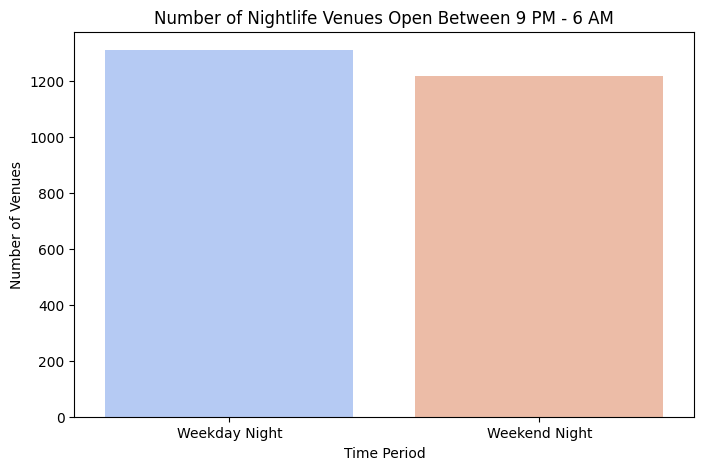

In [31]:
WEEKDAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
WEEKENDS = ['Saturday', 'Sunday']

df_nightlife['open_weekday_night'] = False
df_nightlife['open_weekend_night'] = False

for index, row in df_nightlife.iterrows():
    parsed_hours = row['parsed_hours']
    is_open_weekday = False
    for day in WEEKDAYS:
        if is_open_at_night_robust(parsed_hours, day):
            is_open_weekday = True
            break
    df_nightlife.at[index, 'open_weekday_night'] = is_open_weekday
    is_open_weekend = False
    for day in WEEKENDS:
        if is_open_at_night_robust(parsed_hours, day):
            is_open_weekend = True
            break
    df_nightlife.at[index, 'open_weekend_night'] = is_open_weekend
weekday_night_venues = df_nightlife['open_weekday_night'].sum()
weekend_night_venues = df_nightlife['open_weekend_night'].sum()

print(f"Number of venues open on a weekday night: {weekday_night_venues}")
print(f"Number of venues open on a weekend night: {weekend_night_venues}")

plt.figure(figsize=(8, 5))
sns.barplot(x=['Weekday Night', 'Weekend Night'], y=[weekday_night_venues, weekend_night_venues], palette='coolwarm')
plt.title('Number of Nightlife Venues Open Between 9 PM - 6 AM')
plt.xlabel('Time Period')
plt.ylabel('Number of Venues')
plt.show()

In [32]:
df_nightlife[['name', 'category_list', 'hours', 'parsed_hours', 'open_weekday_night', 'open_weekend_night']].head()

,name,category_list,hours,parsed_hours,open_weekday_night,open_weekend_night
12,Blue Ridge Brewing,[Brewery],"[[Thursday, 4–8PM], [Friday, 4–8PM], [Saturday...","[{'day': 'Thursday', 'hours': '4–8PM'}, {'day'...",True,False
36,Full Moon Saloon,[Bar],None,[],False,False
87,Wild Willy's Casino,[Casino],"[[Wednesday, 8AM–2AM], [Thursday, 8AM–2AM], [F...","[{'day': 'Wednesday', 'hours': '8AM–2AM'}, {'d...",True,True
91,Banjo's Club 109,[Bar],"[[Wednesday, 11AM–9PM], [Thursday, 11AM–9PM], ...","[{'day': 'Wednesday', 'hours': '11AM–9PM'}, {'...",True,True
104,Gold Bar Tavern,[Bar],"[[Wednesday, 9AM–2AM], [Thursday, 9AM–2AM], [F...","[{'day': 'Wednesday', 'hours': '9AM–2AM'}, {'d...",True,True


In [33]:
# Inspect the 'relative_results' column
first_relative_results_entry = df['relative_results'].dropna().iloc[0] if not df['relative_results'].dropna().empty else None

In [34]:
df['relative_results_list'] = df['relative_results'].apply(lambda x: [] if isinstance(x, float) and np.isnan(x) else x)
df[['relative_results', 'relative_results_list']].head()

,relative_results,relative_results_list
0,"[0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6, 0x535d...","[0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6, 0x535d..."
1,"[0x535e993bd79abfed:0xef2dffa2c4d450b1, 0x535e...","[0x535e993bd79abfed:0xef2dffa2c4d450b1, 0x535e..."
2,"[0x535ea2b8fc78a29d:0x4afec6e772204072, 0x535e...","[0x535ea2b8fc78a29d:0x4afec6e772204072, 0x535e..."
3,"[0x535dcdf32d35aa99:0x759cd7bfffe9b23a, 0x535d...","[0x535dcdf32d35aa99:0x759cd7bfffe9b23a, 0x535d..."
4,"[0x535dcde9d8e76fe1:0xe0b24cd42cf705d7, 0x535d...","[0x535dcde9d8e76fe1:0xe0b24cd42cf705d7, 0x535d..."


In [35]:
df_exploded_relative_results = df.explode('relative_results_list')
df_exploded_relative_results[['gmap_id', 'relative_results_list']].head()

,gmap_id,relative_results_list
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcff3914c2049:0x14bb0d04b036a1e6
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcf9353c63d19:0xdded1a1da3db136d
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dce67845bae99:0x5935322a4d6efdb4
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535ddab33551f597:0xc6c66fe54294a498


In [36]:
df_exploded_relative_results = df_exploded_relative_results.rename(columns={'gmap_id': 'original_gmap_id'})

df_relative_categories = pd.merge(
    df_exploded_relative_results,
    df[['gmap_id', 'category_list']],
    left_on='relative_results_list',
    right_on='gmap_id',
    how='left',
    suffixes=('_original', '_relative')
)

df_relative_categories[['original_gmap_id', 'relative_results_list', 'category_list_relative']].head()

,original_gmap_id,relative_results_list,category_list_relative
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6,NaN
1,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcff3914c2049:0x14bb0d04b036a1e6,NaN
2,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcf9353c63d19:0xdded1a1da3db136d,"[Trailer dealer, Horse trailer dealer, Trailer..."
3,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dce67845bae99:0x5935322a4d6efdb4,NaN
4,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535ddab33551f597:0xc6c66fe54294a498,"[Trailer supply store, Truck accessories store]"


In [37]:
df_relative_categories['category_list_relative'] = df_relative_categories['category_list_relative'].apply(lambda x: [] if isinstance(x, float) and np.isnan(x) else x)
all_relative_categories = df_relative_categories.explode('category_list_relative')['category_list_relative']
all_relative_categories = all_relative_categories[all_relative_categories != '']
relative_category_counts = all_relative_categories.value_counts()
top_relative_categories = relative_category_counts.head(N)

print(f"\nTop {N} most frequent categories in 'relative_results':")
display(top_relative_categories)


Top 18 most frequent categories in 'relative_results':


,count
category_list_relative,
Restaurant,4727
Bar,2969
American restaurant,2960
Tourist attraction,2254
Gas station,2000
Fast food restaurant,1983
Auto repair shop,1907
Coffee shop,1857
Grocery store,1767


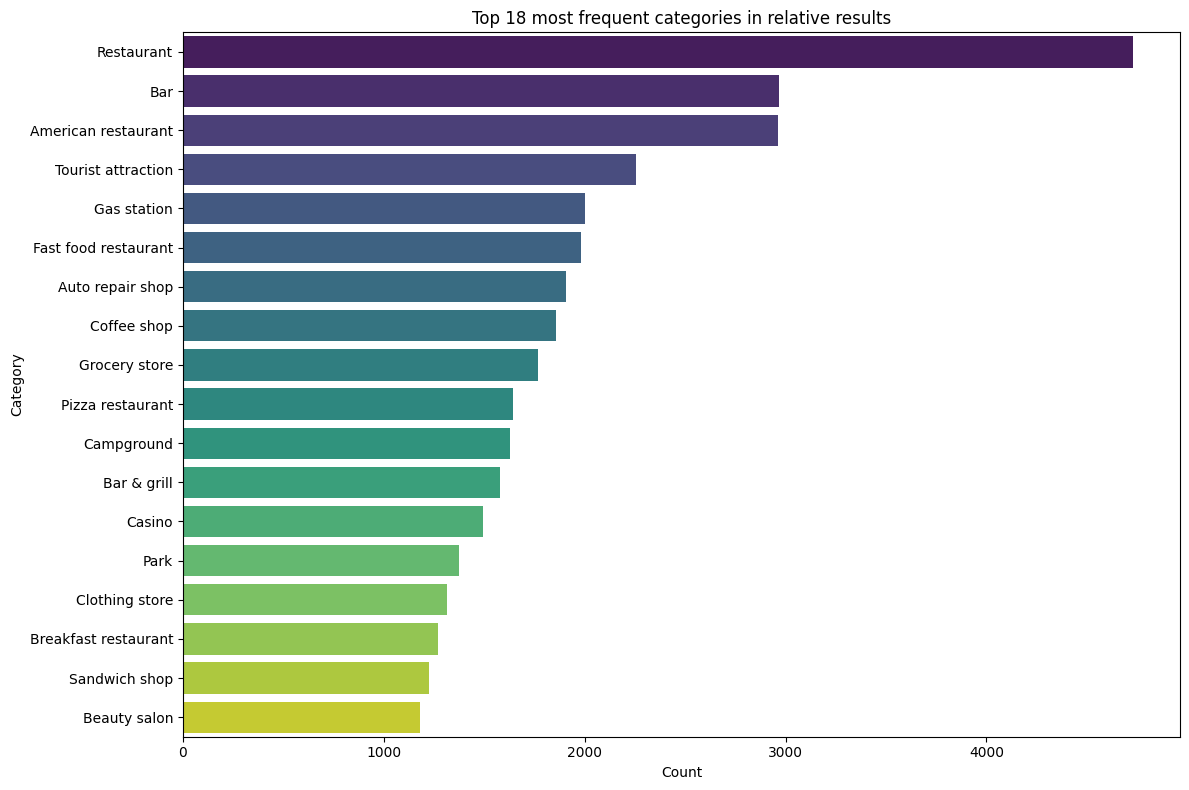

In [38]:
# Visualize the top categories
plt.figure(figsize=(12, 8))
sns.barplot(x=top_relative_categories.values, y=top_relative_categories.index, hue=top_relative_categories.index, palette='viridis', legend=False)
plt.title(f'Top {N} most frequent categories in relative results')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [39]:
coordinates = df[['latitude', 'longitude']].values

print(f"Shape of coordinates array: {coordinates.shape}")
coordinates[:5]

Shape of coordinates array: (21680, 2)


array([[  46.9335221, -114.1065147],
       [  46.5827868, -113.9503241],
       [  46.4991125, -114.0936487],
       [  46.84623  , -114.02682  ],
       [  46.8362233, -114.0415825]])

In [40]:
from scipy.spatial.distance import cdist

distance_matrix = cdist(coordinates, coordinates, metric='euclidean')

print(f"Shape of distance matrix: {distance_matrix.shape}")
print("First 5x5 block of the distance matrix (distances to self should be ~0):")
distance_matrix[:5, :5]

Shape of distance matrix: (21680, 21680)
First 5x5 block of the distance matrix (distances to self should be ~0):


array([[0.        , 0.38394108, 0.43460009, 0.11819964, 0.11697541],
       [0.38394108, 0.        , 0.16596183, 0.27432452, 0.26936621],
       [0.43460009, 0.16596183, 0.        , 0.35349206, 0.34110787],
       [0.11819964, 0.27432452, 0.35349206, 0.        , 0.01783439],
       [0.11697541, 0.26936621, 0.34110787, 0.01783439, 0.        ]])

In [42]:
# For each location, find the indices of its 5 closest neighbors (excluding itself).
# Use argsort to get indices that would sort each row, then take the first 6 (index 0 is itself).
# Exclude the first element (which is always the location itself with distance 0).
closest_neighbors_indices = np.argsort(distance_matrix, axis=1)[:, 1:6]

print("Indices of the 5 closest neighbors for the first 5 locations:")
closest_neighbors_indices[:5]

Indices of the 5 closest neighbors for the first 5 locations:


array([[    0, 13014, 19971,  1639,  3384],
       [    1,  5635,  8209,  1281, 14824],
       [    2, 13055, 20828,  1143, 12090],
       [  149, 12343, 18522,  6495, 18424],
       [  150, 12427, 14958, 15764,   993]])

In [43]:
# First 5 rows of the DataFrame mapping original gmap_id to its closest neighbors' gmap_ids
original_gmap_ids = df['gmap_id'].tolist()
closest_gmap_id_mapping = []

for i, neighbors_indices in enumerate(closest_neighbors_indices):
    original_id = original_gmap_ids[i]
    neighbor_ids = [original_gmap_ids[idx] for idx in neighbors_indices]
    closest_gmap_id_mapping.append({'original_gmap_id': original_id, 'closest_neighbors_gmap_ids': neighbor_ids})

df_closest_neighbors = pd.DataFrame(closest_gmap_id_mapping)
df_closest_neighbors.head()

,original_gmap_id,closest_neighbors_gmap_ids
0,0x535dc557d042b1f3:0xc419b6f55435c7de,"[0x535dc557d042b1f3:0xc419b6f55435c7de, 0x535d..."
1,0x535c2690c357f3bd:0x272620bb52fecf11,"[0x535c2690c357f3bd:0x272620bb52fecf11, 0x535c..."
2,0x535e9ec3ce050deb:0x2169887374ce879f,"[0x535e9ec3ce050deb:0x2169887374ce879f, 0x535e..."
3,0x535dcd8d0868cfd1:0xa4bcdf67cf1f3a76,"[0x535dcd8d0868cfd1:0xa4bcdf67cf1f3a76, 0x535d..."
4,0x56c663acaebf110b:0x117445f25e7e988a,"[0x56c663acaebf110b:0x117445f25e7e988a, 0x535d..."


In [44]:
# First 5 rows of the DataFrame after exploding 'closest_neighbors_gmap_ids
df_closest_neighbors_exploded = df_closest_neighbors.explode('closest_neighbors_gmap_ids')
df_closest_neighbors_exploded.head()

,original_gmap_id,closest_neighbors_gmap_ids
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557d042b1f3:0xc419b6f55435c7de
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535ddab3e143f7d5:0x9db429a96f02d43e
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557c77ea0e7:0xba2708b5f00444ac
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc541c6f41073:0x848b2a8313138a9c
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcff87523a71d:0x4ab86c8240c83da8


In [45]:
# performs two merge operations to attach the category lists of both the original locations
# and their nearest neighbors into a single DataFrame for comparison.
df_final_neighbors = pd.merge(
    df_closest_neighbors_exploded,
    df[['gmap_id', 'category_list']],
    left_on='original_gmap_id',
    right_on='gmap_id',
    how='left'
).rename(columns={'category_list':'category_list_original'}).drop(columns=['gmap_id'])

df_final_neighbors = pd.merge(
    df_final_neighbors,
    df[['gmap_id', 'category_list']],
    left_on='closest_neighbors_gmap_ids',
    right_on='gmap_id',
    how='left'
).rename(columns={'category_list':'category_list_neighbor'}).drop(columns=['gmap_id'])

df_final_neighbors[['original_gmap_id', 'closest_neighbors_gmap_ids', 'category_list_original', 'category_list_neighbor']].head()

,original_gmap_id,closest_neighbors_gmap_ids,category_list_original,category_list_neighbor
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557d042b1f3:0xc419b6f55435c7de,"[Truck accessories store, Diesel engine dealer...","[Truck accessories store, Diesel engine dealer..."
1,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557d042b1f3:0xc419b6f55435c7de,"[Truck accessories store, Diesel engine dealer...","[Truck accessories store, Diesel engine dealer..."
2,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557d042b1f3:0xc419b6f55435c7de,"[Truck accessories store, Diesel engine dealer...","[Truck accessories store, Diesel engine dealer..."
3,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557d042b1f3:0xc419b6f55435c7de,"[Truck accessories store, Diesel engine dealer...","[Truck accessories store, Diesel engine dealer..."
4,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535ddab3e143f7d5:0x9db429a96f02d43e,"[Truck accessories store, Diesel engine dealer...",[RV repair shop]


In [46]:
df_final_neighbors['category_list_neighbor'] = df_final_neighbors['category_list_neighbor'].apply(lambda x: [] if isinstance(x, float) and np.isnan(x) else x)
all_neighbor_categories = df_final_neighbors.explode('category_list_neighbor')['category_list_neighbor']
all_neighbor_categories = all_neighbor_categories[all_neighbor_categories != '']
neighbor_category_counts = all_neighbor_categories.value_counts()
top_neighbor_categories = neighbor_category_counts.head(N)

print(f"\nTop {N} most frequent categories among closest neighbors:")
top_neighbor_categories


Top 18 most frequent categories among closest neighbors:


,count
category_list_neighbor,
Restaurant,6428
Bar,4058
Gas station,4019
Coffee shop,2687
Auto repair shop,2526
Fast food restaurant,2499
Tourist attraction,2428
American restaurant,2347
Casino,2331


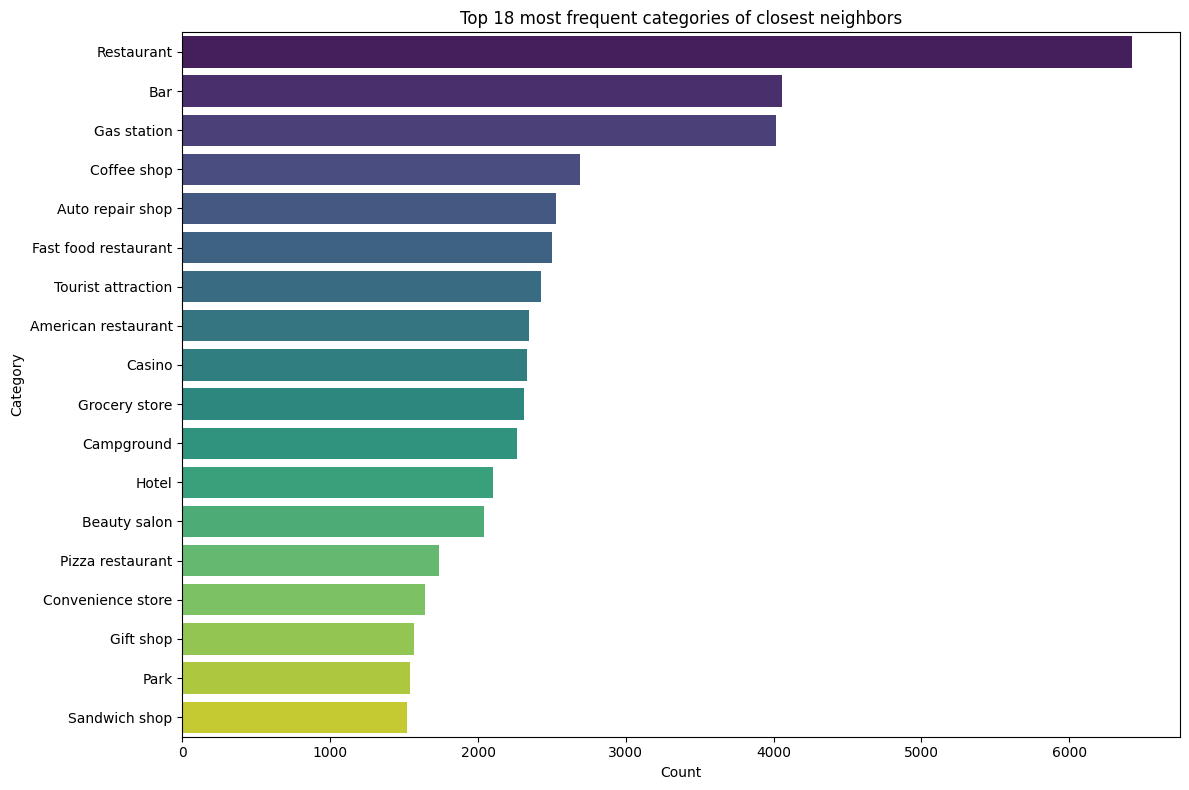

In [47]:
# Visualize the top categories
plt.figure(figsize=(12, 8))
sns.barplot(x=top_neighbor_categories.values, y=top_neighbor_categories.index, hue=top_neighbor_categories.index, palette='viridis', legend=False)
plt.title(f'Top {N} most frequent categories of closest neighbors')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()